# EchoScope: Spotify Track Analysis & Recommendation System

## Popularity Prediction

### Set up the libraries and the dataset

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split # Splitting between training and testing dataset.
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier # Implementing the random forest.
from sklearn.metrics import mean_absolute_error, r2_score # Accuracy metrics.
import seaborn as sns # Plotting.
import matplotlib.pyplot as plt # Plotting.

clustered_tracks_df = pd.read_csv('dataset_clustered.csv')
clustered_dummies_df = pd.get_dummies(clustered_tracks_df, columns=['cluster'], prefix='cluster') # Create one-hot encodings for each cluster.

#  Define the features and the target.
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 
                  'explicit', 'mode']
cluster_features = [col for col in clustered_dummies_df.columns if col.startswith('cluster_')]
features = audio_features + cluster_features

X = clustered_dummies_df[features] # Numeric features (except for popularity) and cluster encodings.
y = clustered_dummies_df['popularity'] # Popularity.

# Split between the training dataset, which will contain 80% of the dataset, and the testing dataset, which will contain the remaining 20% of the dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Implement the random forest

Note that using the random forest regressor allows to weigh song features depending on the corresponding cluster, allowing to obtain more interpretable popularity scores.

In [25]:
# Start by initializing the model.
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10, random_state=26, n_jobs=-1)

# Run the random forest
rf.fit(X_train, y_train) # Fitting on the training dataset.
y_pred = rf.predict(X_test) # Predictions on the testing dataset.

Now, use the mean absolute error and the determinantion coefficient to understand the goodness of the predictions.

In [26]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} Points.")
print(f"R2 Score: {r2:.2f}.")

Mean Absolute Error: 14.68 Points.
R2 Score: 0.32.


Check whether a song is going to be popular or not. <br>
In this setting, a popularity threshold score of 70 is used, although this can be changed.

Before making predictions on popularity, consider plotting songs popularity within each cluster to see what would be considered a suitable threshold for each song.

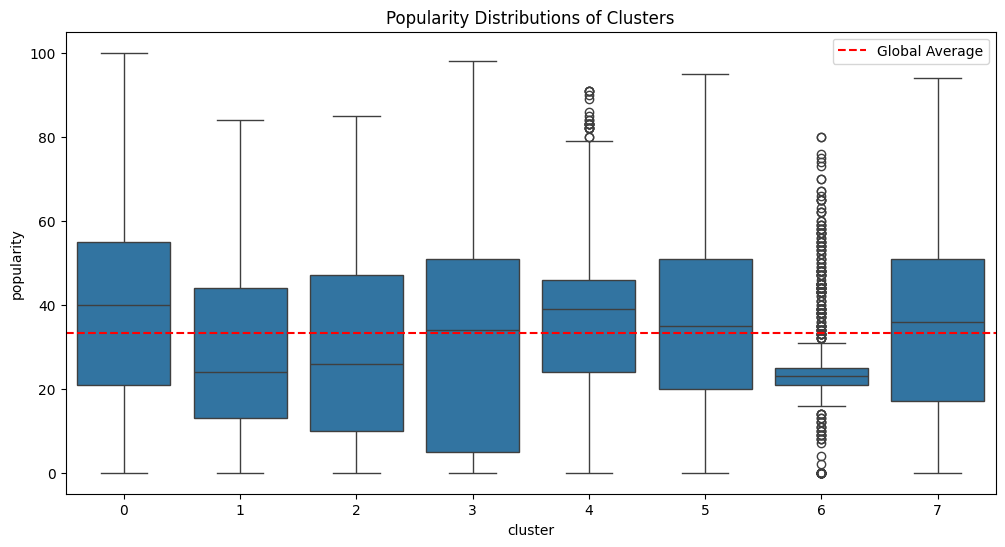

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster', y='popularity', data=clustered_tracks_df)
plt.title('Popularity Distributions of Clusters')
plt.axhline(clustered_tracks_df['popularity'].mean(), color='red', linestyle='--', label='Global Average')
plt.legend()
plt.show()

Then, create a dynamic threshold for each cluster by considering the third quartile of its popularity distribution. <br>
In this way, a song will be popular if it is in the top $25\%$ scores for its group.

In [28]:
dynamic_thresholds = clustered_tracks_df.groupby('cluster')['popularity'].quantile(0.75).to_dict()

# Print the popularity thresholds for each clusters.
print("Popularity Thresholds of Clusters (Top 25%):")
for cluster, threshold in dynamic_thresholds.items():
    print(f"Cluster {cluster}: {threshold:.2f}")

Popularity Thresholds of Clusters (Top 25%):
Cluster 0: 55.00
Cluster 1: 44.00
Cluster 2: 47.00
Cluster 3: 51.00
Cluster 4: 46.00
Cluster 5: 51.00
Cluster 6: 25.00
Cluster 7: 51.00


In [30]:
def evaluate_song_potential(model, song_data, thresholds):
    # Start by predicting the popularity score.
    predicted_score = model.predict(song_data)[0]
    # Find the corresponding cluster.
    current_cluster_col = song_data.columns[(song_data == 1).iloc[0]].tolist()
    cluster_id_col = [c for c in current_cluster_col if c.startswith('cluster_')][0]
    cluster_id = int(cluster_id_col.split('_')[1])
    # Find the threshold popularity score for that cluster.
    threshold = thresholds[cluster_id] # Assume the cluster is always present.
    return cluster_id, score, threshold, score >= threshold

# Check an example from the testing dataset.
test_song = X_test.iloc[[0]]
cid, score, thr, is_hit = evaluate_song_potential(rf, test_song, dynamic_thresholds)
print(f"--- Test Results ---")
print(f"Cluster: {cid}")
print(f"Predicted Popularity: {round(score, 2)} / 100")
print(f"Cluster Threshold: {thr}")
print(f"Status: {'🔥 Hit' if is_hit else '📈 Standard'}")

--- Test Results ---
Cluster: 0
Predicted Popularity: 43.51 / 100
Cluster Threshold: 55.0
Status: 📈 Standard


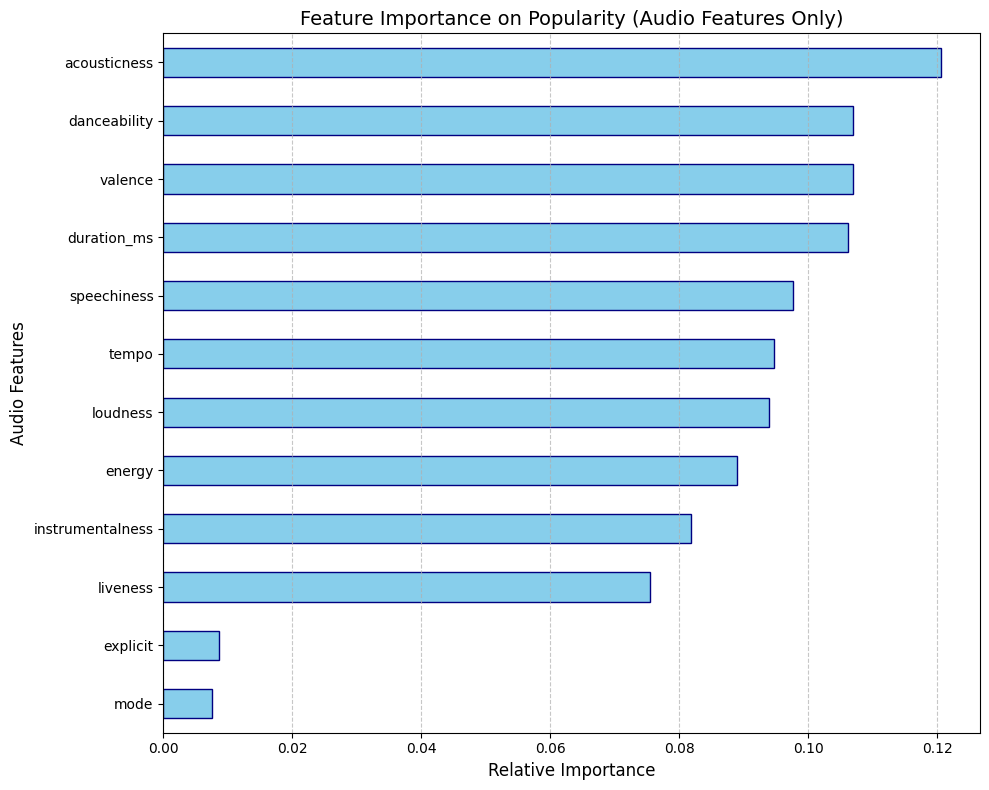

In [31]:
# Derive feature importance.
all_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True) # Sort in descending order for the plot.

# Remove the one-hot encoding features.
importances_audio_only = all_importances[~all_importances.index.str.startswith('cluster_')] # The ~ is used to invert a command.

# Plot feature importance.
plt.figure(figsize=(10, 8))
importances_audio_only.plot(kind='barh', color='skyblue', edgecolor='navy')

# Add details for readability.
plt.title('Feature Importance on Popularity (Audio Features Only)', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Audio Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This plot shows that acousticness appears to be the most important feature for popularity evaluation. <br>
Note that the binary features, like explicit and mode, also happen to be the least relevant features in this evaluation.

### Save the resulting dataframe

In [32]:
clustered_tracks_df['popularity_pred'] = rf.predict(X)
clustered_tracks_df.to_csv('../EchoScope/dataset_popularity.csv', index=False) # Useful for the song recommendation system.